In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [2]:
df1 = pd.read_csv(r"C:\Users\deves\Downloads\archive (10)\premier_league_table.csv")
df2 = pd.read_csv(r"C:\Users\deves\Downloads\archive (10)\premier_league_table (1).csv")

df = pd.concat([df1, df2], ignore_index=True)

print("Shape:", df.shape)
df.head()

Shape: (40, 9)


,Team,Played,Won,Drawn,Lost,Goals For,Goals Against,Goal Difference,Points
0,Arsenal,13,9,3,1,25,7,18,30
1,Manchester City,13,8,1,4,27,12,15,25
2,Chelsea,13,7,3,3,24,12,12,24
3,Aston Villa,13,7,3,3,16,11,5,24
4,Brighton & Hove Albion,13,6,4,3,21,16,5,22


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Team             40 non-null     object
 1   Played           40 non-null     int64 
 2   Won              40 non-null     int64 
 3   Drawn            40 non-null     int64 
 4   Lost             40 non-null     int64 
 5   Goals For        40 non-null     int64 
 6   Goals Against    40 non-null     int64 
 7   Goal Difference  40 non-null     int64 
 8   Points           40 non-null     int64 
dtypes: int64(8), object(1)
memory usage: 2.9+ KB


,Played,Won,Drawn,Lost,Goals For,Goals Against,Goal Difference,Points
count,40.00000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000
mean,13.50000,5.375000,2.750000,5.375000,18.825000,18.825000,0.000000,18.875000
std,0.50637,2.120565,1.255756,2.518521,5.083344,5.935065,9.711215,6.564034
min,13.00000,0.000000,0.000000,1.000000,7.000000,7.000000,-22.000000,2.000000
25%,13.00000,4.750000,2.000000,3.750000,15.000000,14.750000,-4.250000,16.500000
50%,13.50000,5.500000,3.000000,5.000000,19.000000,19.000000,1.000000,19.000000
75%,14.00000,6.250000,4.000000,7.000000,21.000000,22.250000,5.000000,22.250000
max,14.00000,10.000000,5.000000,12.000000,32.000000,29.000000,20.000000,33.000000


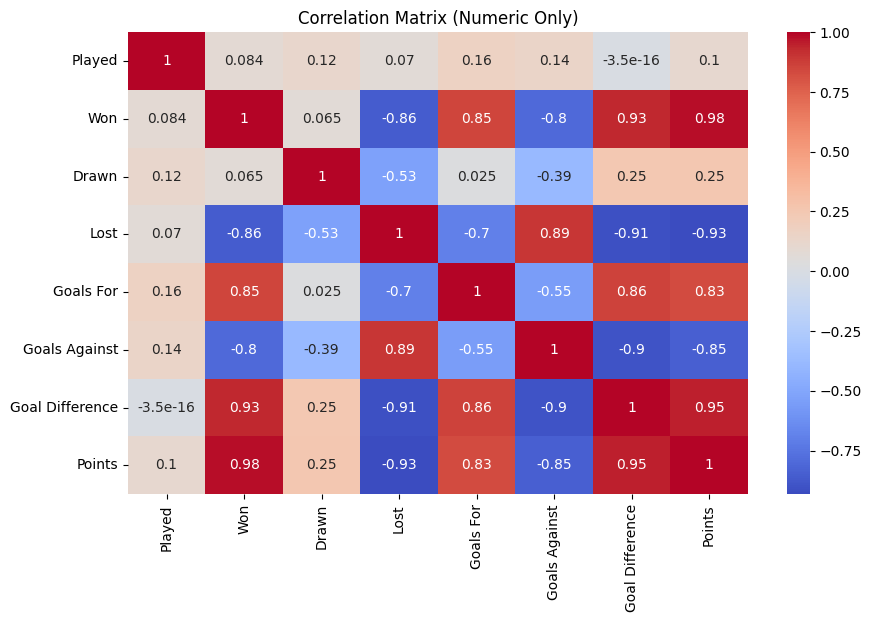

In [5]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix (Numeric Only)")
plt.show()

In [7]:
features = ["Played", "Won", "Drawn", "Lost", "Goals For",
            "Goals Against", "Goal Difference"]

X = df[features]
y = df["Points"]

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Linear Regression Results:")
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("R2 Score:", r2_score(y_test, y_pred_lr))

Linear Regression Results:
MAE: 5.440092820663267e-15
RMSE: 6.915539919559704e-15
R2 Score: 1.0


In [9]:
rf = RandomForestRegressor(n_estimators=500, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Results:")
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("R2 Score:", r2_score(y_test, y_pred_rf))

Random Forest Results:
MAE: 1.202
RMSE: 1.8671700511737006
R2 Score: 0.9222832685475444


In [10]:
gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

print("Gradient Boosting Results:")
print("MAE:", mean_absolute_error(y_test, y_pred_gb))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_gb)))
print("R2 Score:", r2_score(y_test, y_pred_gb))

Gradient Boosting Results:
MAE: 1.1230690377277055
RMSE: 1.813517118148242
R2 Score: 0.9266854623405542


In [11]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "Gradient Boosting"],
    "MAE": [
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y_test, y_pred_rf),
        mean_absolute_error(y_test, y_pred_gb)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf)),
        np.sqrt(mean_squared_error(y_test, y_pred_gb))
    ],
    "R2 Score": [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_gb)
    ]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,5.440093e-15,6.915540e-15,1.000000
1,Random Forest,1.202000e+00,1.867170e+00,0.922283
2,Gradient Boosting,1.123069e+00,1.813517e+00,0.926685


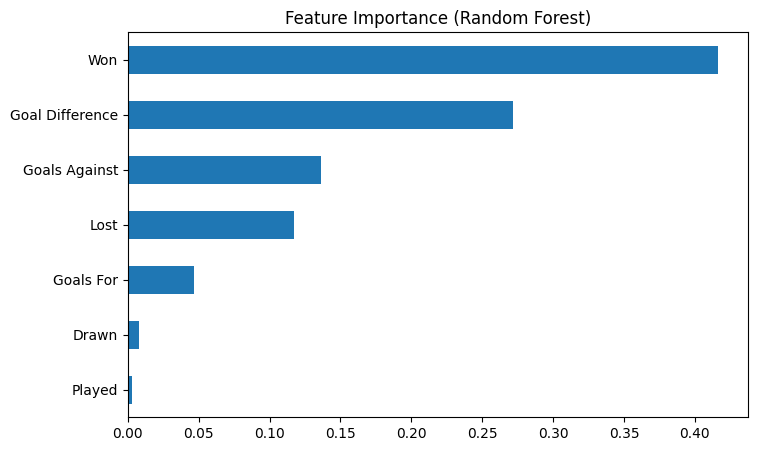

In [12]:
importances = pd.Series(rf.feature_importances_, index=features)
importances.sort_values().plot(kind="barh", figsize=(8,5))
plt.title("Feature Importance (Random Forest)")
plt.show()

In [13]:
example = pd.DataFrame({
    "Played": [14],
    "Won": [8],
    "Drawn": [3],
    "Lost": [3],
    "Goals For": [20],
    "Goals Against": [12],
    "Goal Difference": [8]
})

predicted_points = rf.predict(example)[0]
print("Predicted Points:", predicted_points)

Predicted Points: 25.466
